# Water Tank Leakage Detection — POC

A **behavior-based**, fully **explainable** detection pipeline for abnormal
continuous water consumption caused by leakage.

**Objective**: learn each user's normal consumption behaviour (when they use
water, for how long, at what rate) and flag *continuous abnormal* consumption
that deviates from that learned profile — without forecasting and without
black-box ML.

Only available signal: `timestamp, water_level` from a single in-tank sensor.

Constraints honoured by this POC:
* No LSTM / Transformers / forecasting models.
* No Isolation Forest or other anomaly-detection ML.
* Detection is rule-based on signal processing, statistics and behavior profiling.
* ML may be added later **only if** it beats this baseline on False-Alarm Rate.

---

### Pipeline stages
1. Data loading + dataset summary
2. Signal cleaning (rolling median, deadband, refill detection)
3. Consumption-event detection
4. User behaviour profile
5. Leak-detection rule engine (Rules A / B / C)
6. Evaluation: randomized synthetic-injection grid
7. Final combined visualization
8. Summary & next steps


## 0. Configuration

A single `Config` dataclass holds every tunable constant and threshold. No
magic numbers are scattered through the notebook — change a value here and
re-run.


In [100]:
from dataclasses import dataclass, asdict
from pathlib import Path
import json


@dataclass
class Config:
    # --- physical / sensor constants ---
    sampling_interval_seconds: int = 300          # 5-minute sensor cadence
    tank_height: float = 4.0                      # full-tank level (from data max)
    tank_area: float | None = None                # optional cross-section -> enables volume
    sensor_deadband: float = 0.005                 # |dLevel| <= this is sensor noise (flat)

    # --- signal cleaning ---
    rolling_window: int = 5                       # 5 samples = 25 min rolling median
    refill_consecutive_pos: int = 3                # N consecutive rise-samples -> refill

    # --- event extraction ---
    min_event_samples: int = 2                    # ignore 1-sample blips
    idle_gap_minutes: int = 15                    # gap > this splits two events

    # --- behavior profile ---
    low_activity_percentile: float = 33.0         # bottom ~33% hours -> up to 8 "quiet hours"
    night_hours: tuple[int, ...] = (23, 0, 1, 2, 3, 4, 5)

    # --- Rule A: unusual-hour long drain ---
    rule_a_min_unusual_prob: float = 0.25         # hour activity prob below this = unusual
    rule_a_dur_mult: float = 1.5                  # event duration > per-hour p95 * mult

    # --- Rule B: slow night leak (linear trend) ---
    rule_b_min_quiet_hours: float = 4.0           # sustained window length
    rule_b_alpha: float = 0.01                    # significance level (p-value)
    rule_b_slope_mult: float = 2.0                # |slope| > baseline * mult
    rule_b_step_minutes: int = 60                 # sliding-window step

    # --- Rule C: hard duration cap ---
    rule_c_max_duration_hours: float = 4.0        # any drain > this is a leak

    # --- evaluation ---
    num_random_scenarios: int = 30
    random_seed: int = 42
    detection_overlap_threshold: float = 0.3      # IoU-style overlap with injected window

    # --- paths ---
    data_path: str = "data/water_tank_level_30days.csv"
    events_out: str = "data/events.parquet"
    profile_out: str = "data/profile.json"


cfg = Config()
DATA_PATH = Path(cfg.data_path)
Path("data").mkdir(exist_ok=True)
print("Config loaded:", json.dumps(asdict(cfg), indent=2, default=str))

Config loaded: {
  "sampling_interval_seconds": 300,
  "tank_height": 4.0,
  "tank_area": null,
  "sensor_deadband": 0.005,
  "rolling_window": 5,
  "refill_consecutive_pos": 3,
  "min_event_samples": 2,
  "idle_gap_minutes": 15,
  "low_activity_percentile": 33.0,
  "night_hours": [
    23,
    0,
    1,
    2,
    3,
    4,
    5
  ],
  "rule_a_min_unusual_prob": 0.25,
  "rule_a_dur_mult": 1.5,
  "rule_b_min_quiet_hours": 4.0,
  "rule_b_alpha": 0.01,
  "rule_b_slope_mult": 2.0,
  "rule_b_step_minutes": 60,
  "rule_c_max_duration_hours": 4.0,
  "num_random_scenarios": 30,
  "random_seed": 42,
  "detection_overlap_threshold": 0.3,
  "data_path": "data/water_tank_level_30days.csv",
  "events_out": "data/events.parquet",
  "profile_out": "data/profile.json"
}


## 1. Stage 1 — Data Loading & Dataset Summary

Load, parse datetime, sort, validate cadence, and print a compact summary so
the POC is self-documenting.


In [101]:
import pandas as pd
import numpy as np

raw = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
raw = raw.sort_values("datetime").reset_index(drop=True)

# --- validation ---
expected_td = pd.Timedelta(seconds=cfg.sampling_interval_seconds)
dt_diff = raw["datetime"].diff().dt.total_seconds().dropna()
cadence_ok = bool((dt_diff == cfg.sampling_interval_seconds).all())
n_dup = int(raw["datetime"].duplicated().sum())
n_missing_level = int(raw["water_level"].isna().sum())

summary = {
    "rows": len(raw),
    "start": str(raw["datetime"].iloc[0]),
    "end": str(raw["datetime"].iloc[-1]),
    "inferred_interval_min": (dt_diff.median() / 60.0) if len(dt_diff) else None,
    "cadence_regular": cadence_ok,
    "duplicate_rows": n_dup,
    "missing_values": n_missing_level,
    "level_min": float(raw["water_level"].min()),
    "level_max": float(raw["water_level"].max()),
    "level_mean": float(raw["water_level"].mean()),
}
print("Dataset Summary")
print("-" * 40)
for k, v in summary.items():
    print(f"{k:>22}: {v}")

# dedup + interpolate small gaps defensively (dataset is clean, but stay robust)
df = raw.drop_duplicates("datetime").set_index("datetime").sort_index()
df = df.asfreq(expected_td)                       # expose any gaps as NaN
n_gaps = int(df["water_level"].isna().sum())
if n_gaps:
    df["water_level"] = df["water_level"].interpolate(method="time", limit=3)
print(f"\nDetected {n_gaps} missing rows after reindex; interpolated (<=3 each).")
print(f"Working series length: {len(df)} samples over {(df.index[-1]-df.index[0]).days} days.")


Dataset Summary
----------------------------------------
                  rows: 8640
                 start: 2025-04-01 00:00:00
                   end: 2025-04-30 23:55:00
 inferred_interval_min: 5.0
       cadence_regular: True
        duplicate_rows: 0
        missing_values: 0
             level_min: 0.492
             level_max: 4.0
            level_mean: 2.4881208333333333

Detected 0 missing rows after reindex; interpolated (<=3 each).
Working series length: 8640 samples over 29 days.


## 2. Stage 2 — Signal Cleaning

1. Rolling median to suppress sensor jitter.
2. First difference on the **smoothed** signal, classified through a
   **deadband** (`sensor_deadband`): small fluctuations collapse to `flat`.
3. **Refill detection** only after `refill_consecutive_pos` consecutive rise
   samples — a single positive blip never triggers refill.


In [102]:
level = df["water_level"].astype(float)

# rolling median smoothing
smoothed = level.rolling(window=cfg.rolling_window, center=True, min_periods=1).median()

# first difference + deadband classification
delta = smoothed.diff()
def classify(d):
    if pd.isna(d):
        return "flat"
    if d > cfg.sensor_deadband:
        return "rise"
    if d < -cfg.sensor_deadband:
        return "drop"
    return "flat"
movement = delta.apply(classify)

# refill detection: N consecutive 'rise' samples
is_rise = (movement == "rise").to_numpy()
refill_mask = np.zeros(len(smoothed), dtype=bool)
consec = 0
for i in range(len(smoothed)):
    if is_rise[i]:
        consec += 1
        if consec >= cfg.refill_consecutive_pos:
            # mark the whole run (this sample + the previous N-1)
            refill_mask[i - consec + 1 : i + 1] = True
    else:
        consec = 0

clean = smoothed.copy()
clean.loc[refill_mask] = np.nan      # exclude refill periods from drain analysis

df = df.assign(
    level_raw=level,
    level_smooth=smoothed,
    movement=movement,
    is_refill=refill_mask,
)

n_refill = int(refill_mask.sum())
pct_refill = 100 * n_refill / len(df)
print(f"Refill samples detected: {n_refill} ({pct_refill:.1f}%)")
print(f"Movement counts:\n{movement.value_counts().to_string()}")


Refill samples detected: 200 (2.3%)
Movement counts:
water_level
flat    6559
drop    1879
rise     202


In [103]:
#df.iloc[210:270]

In [104]:
len(df)

8640

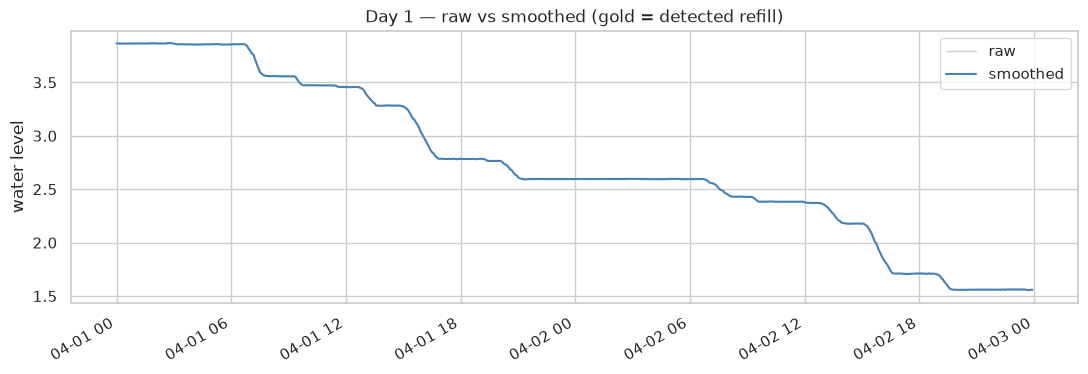

In [105]:
# quick sanity plot: day 1 zoom (raw vs smoothed, deadband band, refill shading)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

day1 = df.loc["2025-04-01":"2025-04-02"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(day1.index, day1["level_raw"], color="lightgray", lw=1, label="raw")
ax.plot(day1.index, day1["level_smooth"], color="steelblue", lw=1.5, label="smoothed")
# refill shading
r = day1["is_refill"]
runs = (~r.eq(r.shift(1).fillna(False))).cumsum()
for _, g in day1.groupby(runs):
    if g["is_refill"].iat[0]:
        ax.axvspan(g.index[0], g.index[-1], color="gold", alpha=0.18)
ax.set_title("Day 1 — raw vs smoothed (gold = detected refill)")
ax.set_ylabel("water level"); ax.legend(loc="upper right")
fig.autofmt_xdate(); plt.show()


## 3. Stage 3 — Consumption Event Detection

Convert the cleaned time series into a table of **consumption events** (every
continuous drain outside refill / idle gaps becomes one row). These events —
not the raw readings — are the unit of behaviour analysis and leak detection.


In [106]:
def extract_events(df_in: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    mov = df_in["movement"].to_numpy()
    refill = df_in["is_refill"].to_numpy()
    lvl = df_in["level_smooth"].to_numpy()
    idx = df_in.index

    events = []
    i = 0
    n = len(df_in)
    while i < n:
        if mov[i] == "drop" and not refill[i]:
            # start a new event
            j = i
            # accumulate drop samples; allow brief flat stretches inside an event
            # only refill, idle-gap, or end of series terminates it
            last_drop = i
            while j < n:
                if mov[j] == "drop" and not refill[j]:
                    last_drop = j
                    j += 1
                elif mov[j] == "flat" and not refill[j]:
                    # check idle gap: how long flat?
                    k = j
                    while k < n and mov[k] == "flat" and not refill[k]:
                        k += 1
                    flat_minutes = (idx[k-1] - idx[j-1]).total_seconds() / 60 if k > j else 0
                    if flat_minutes >= cfg.idle_gap_minutes or k >= n:
                        break
                    else:
                        j = k
                else:  # rise or refill -> event ends
                    break
            end = last_drop
            seg_lvl = lvl[i:end+1]
            seg_t = idx[i:end+1]
            duration_min = (seg_t[-1] - seg_t[0]).total_seconds() / 60.0
            n_samples = end - i + 1
            if n_samples >= cfg.min_event_samples and duration_min > 0:
                drops = np.diff(seg_lvl)
                total_drop = float(seg_lvl[0] - seg_lvl[-1])
                mean_drop_rate = float(total_drop / duration_min) if duration_min else 0.0
                rate_variance = float(np.var(drops)) if len(drops) > 1 else 0.0
                start = seg_t[0]
                volume = (total_drop * cfg.tank_area) if cfg.tank_area is not None else None
                events.append({
                    "start_time": start, "end_time": seg_t[-1],
                    "duration_minutes": duration_min, "num_samples": n_samples,
                    "total_drop": total_drop, "mean_drop_rate": mean_drop_rate,
                    "rate_variance": rate_variance,
                    "start_hour": start.hour, "weekday": int(start.dayofweek),
                    "is_night": any((seg_t[h].hour in cfg.night_hours) for h in range(len(seg_t))),
                    "total_volume": volume,
                })
            i = max(end + 1, i + 1)
        else:
            i += 1
    ev = pd.DataFrame(events)
    return ev


events = extract_events(df, cfg)
print(f"Extracted {len(events)} consumption events over {(df.index[-1]-df.index[0]).days} days.")
events.head(10)


Extracted 148 consumption events over 29 days.


,start_time,end_time,duration_minutes,num_samples,total_drop,mean_drop_rate,rate_variance,start_hour,weekday,is_night,total_volume
0,2025-04-01 06:50:00,2025-04-01 07:45:00,55.0,12,0.276,0.005018,0.000161,6,1,False,None
1,2025-04-01 09:25:00,2025-04-01 09:45:00,20.0,5,0.064,0.003200,0.000027,9,1,False,None
2,2025-04-01 12:45:00,2025-04-01 13:35:00,50.0,11,0.166,0.003320,0.000031,12,1,False,None
3,2025-04-01 15:05:00,2025-04-01 16:50:00,105.0,22,0.480,0.004571,0.000060,15,1,False,None
4,2025-04-01 19:20:00,2025-04-01 19:25:00,5.0,2,0.009,0.001800,0.000000,19,1,False,None
5,2025-04-01 20:10:00,2025-04-01 21:10:00,60.0,13,0.160,0.002667,0.000035,20,1,False,None
6,2025-04-02 06:50:00,2025-04-02 08:05:00,75.0,16,0.151,0.002013,0.000024,6,2,False,None
7,2025-04-02 09:20:00,2025-04-02 09:35:00,15.0,4,0.035,0.002333,0.000003,9,2,False,None
8,2025-04-02 12:55:00,2025-04-02 13:55:00,60.0,13,0.174,0.002900,0.000029,12,2,False,None
9,2025-04-02 15:10:00,2025-04-02 16:35:00,85.0,18,0.450,0.005294,0.000075,15,2,False,None


In [107]:
events["total_volume"].value_counts()

Series([], Name: count, dtype: int64)

## 4. Stage 4 — User Behaviour Profile

Learn *when* and *how long* the user normally consumes water, **per hour**
(so 3PM irrigation is distinguished from an 8AM tap). Quiet hours are the
bottom `low_activity_percentile` of activity probability. The profile is
persisted to `data/profile.json` and events to `data/events.parquet`.


In [108]:
def build_profile(events: pd.DataFrame, df_in: pd.DataFrame, cfg: Config) -> dict:
    n_days = (df_in.index[-1] - df_in.index[0]).days + 1

    # hourly activity probability: fraction of days with >=1 event touching that hour
    hourly_active = np.zeros(24)
    for _, e in events.iterrows():
        if pd.isna(e["start_time"]):
            continue
        covers = pd.date_range(e["start_time"], e["end_time"], freq="5min")
        days = covers.normalize().unique()
        hours = set(covers.hour)
        for h in hours:
            hourly_active[h] += len(days)
    hourly_active_prob = (hourly_active / n_days).clip(0, 1)

    # per-hour typical duration (median + p95) for events starting in that hour
    per_hour_dur = {h: {"median": None, "p95": None, "count": 0} for h in range(24)}
    for h in range(24):
        eh = events[events["start_hour"] == h]["duration_minutes"]
        if len(eh):
            per_hour_dur[h] = {
                "median": float(eh.median()),
                "p95": float(eh.quantile(0.95)),
                "count": int(len(eh)),
            }

    # quiet hours: bottom low_activity_percentile of activity probability
    thresh = np.percentile(hourly_active_prob, cfg.low_activity_percentile)
    quiet_hours = [h for h in range(24) if hourly_active_prob[h] <= thresh + 1e-9]

    # global duration stats
    dur = events["duration_minutes"]
    global_dur = {
        "mean": float(dur.mean()), "median": float(dur.median()),
        "p95": float(dur.quantile(0.95)), "max": float(dur.max()),
    }

    # quiet-hour baseline slope: median slope of level over quiet windows (no events)
    # computed from the cleaned (non-refill) series
    quiet_mask = df_in.index.hour.isin(quiet_hours)
    qs = df_in.loc[quiet_mask & ~df_in["is_refill"], "level_smooth"].dropna()
    slopes = []
    # sliding 1h windows inside quiet periods
    if len(qs) > 12:
        for w_start in range(0, len(qs) - 12, 12):
            w = qs.iloc[w_start:w_start+13]
            if len(w) >= 10:
                from scipy.stats import linregress
                x = (w.index - w.index[0]).total_seconds().to_numpy() / 60.0
                res = linregress(x, w.to_numpy())
                slopes.append(res.slope)
    quiet_baseline_slope = float(np.median(slopes)) if slopes else 0.0

    profile = {
        "n_days": n_days,
        "hourly_active_prob": {int(h): float(p) for h, p in enumerate(hourly_active_prob)},
        "per_hour_duration": {int(h): per_hour_dur[h] for h in range(24)},
        "quiet_hours": sorted(quiet_hours),
        "quiet_activity_threshold": float(thresh),
        "global_duration": global_dur,
        "quiet_baseline_slope": quiet_baseline_slope,
        "config": asdict(cfg),
    }
    return profile


profile = build_profile(events, df, cfg)
print("Quiet hours:", profile["quiet_hours"])
print("Hourly activity probability:")
for h in range(24):
    bar = "#" * int(profile["hourly_active_prob"][h] * 40)
    print(f"{h:02d}h | {profile['hourly_active_prob'][h]:.2f} | {bar}")
print("\nGlobal duration stats:", profile["global_duration"])
print("Quiet baseline slope (level/min):", profile["quiet_baseline_slope"])

# backfill is_quiet_hour onto events
qh = set(profile["quiet_hours"])
events["is_quiet_hour"] = events["start_hour"].isin(qh)

# persist
Path(cfg.profile_out).write_text(json.dumps(profile, indent=2, default=str))
events.to_parquet(cfg.events_out, index=False)
print(f"\nSaved profile -> {cfg.profile_out}  ({len(events)} events -> {cfg.events_out})")


Quiet hours: [0, 1, 2, 3, 4, 5, 18, 21, 22, 23]
Hourly activity probability:
00h | 0.13 | #####
01h | 0.17 | ######
02h | 0.17 | ######
03h | 0.13 | #####
04h | 0.07 | ##
05h | 0.03 | #
06h | 0.53 | #####################
07h | 0.90 | ####################################
08h | 0.57 | ######################
09h | 0.47 | ##################
10h | 0.33 | #############
11h | 0.27 | ##########
12h | 0.77 | ##############################
13h | 0.90 | ####################################
14h | 0.37 | ##############
15h | 0.93 | #####################################
16h | 0.93 | #####################################
17h | 0.30 | ############
18h | 0.17 | ######
19h | 0.87 | ##################################
20h | 0.67 | ##########################
21h | 0.10 | ####
22h | 0.03 | #
23h | 0.00 | 

Global duration stats: {'mean': 59.560810810810814, 'median': 55.0, 'p95': 125.0, 'max': 250.0}
Quiet baseline slope (level/min): -1.5384615384617105e-05

Saved profile -> data/profile.json  (148 events -

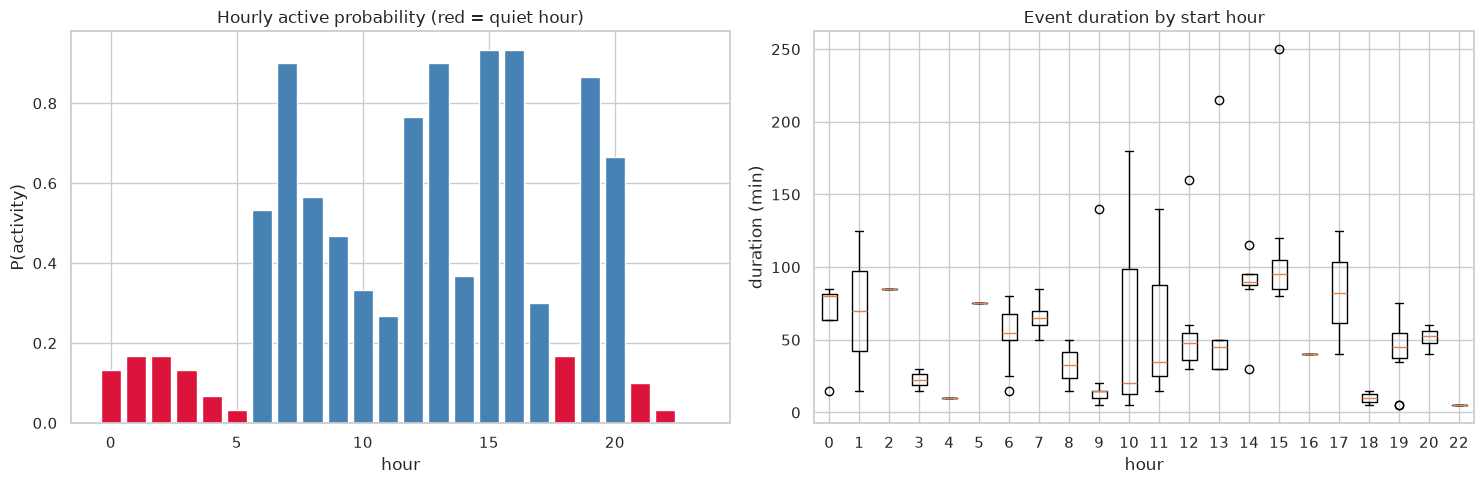

In [109]:
# profile visualization: hourly activity + per-hour duration boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# activity bar
ax = axes[0]
probs = [profile["hourly_active_prob"][h] for h in range(24)]
colors = ["crimson" if h in profile["quiet_hours"] else "steelblue" for h in range(24)]
ax.bar(range(24), probs, color=colors)
ax.set_title("Hourly active probability (red = quiet hour)")
ax.set_xlabel("hour"); ax.set_ylabel("P(activity)")

# per-hour duration boxplot
ax = axes[1]
data = []
labels = []
for h in range(24):
    eh = events[events["start_hour"] == h]["duration_minutes"]
    if len(eh):
        data.append(eh.values); labels.append(str(h))
ax.boxplot(data, tick_labels=labels, showfliers=True)
ax.set_title("Event duration by start hour")
ax.set_xlabel("hour"); ax.set_ylabel("duration (min)")
plt.tight_layout(); plt.show()


## 5. Stage 5 — Leak Detection Rule Engine

Three independent, explainable rules. Each returns an `Alert` with the firing
rule and a human-readable reason.

* **Rule A — unusual-hour long drain**: starts in a low-activity hour AND lasts
  longer than that hour's typical p95 duration.
* **Rule B — slow night leak**: during quiet hours, a sliding `linregress`
  finds a statistically significant, baseline-exceeding negative trend.
* **Rule C — hard duration cap**: any event longer than
  `rule_c_max_duration_hours`, regardless of time.


In [110]:
from scipy.stats import linregress
from dataclasses import dataclass

@dataclass
class Alert:
    start: pd.Timestamp
    end: pd.Timestamp
    rule: str
    reason: str
    score: float


def rule_a(ev_row, profile, cfg) -> Alert | None:
    h = int(ev_row["start_hour"])
    prob = profile["hourly_active_prob"][h]
    dur_p95 = profile["per_hour_duration"][h]["p95"]
    if dur_p95 is None:
        dur_p95 = profile["global_duration"]["p95"]
    if (prob < cfg.rule_a_min_unusual_prob
            and ev_row["duration_minutes"] > cfg.rule_a_dur_mult * dur_p95
            and ev_row["duration_minutes"] >= 30):
        reason = (f"Rule A: event at {ev_row['start_time']} lasted "
                  f"{ev_row['duration_minutes']:.0f} min vs p95 {dur_p95:.0f} min "
                  f"at hour {h:02d} (activity prob {prob:.2f})")
        return Alert(ev_row["start_time"], ev_row["end_time"], "A", reason,
                     float(ev_row["duration_minutes"]))
    return None


def rule_b(df_in, profile, cfg) -> list[Alert]:
    alerts = []
    quiet = set(profile["quiet_hours"])
    # build maximal quiet-hour windows (contiguous in time)
    isq = df_in.index.hour.isin(quiet) & ~df_in["is_refill"]
    runs = (~isq.eq(isq.shift(1).fillna(False))).cumsum()
    for run_id, g in df_in.groupby(runs):
        if not isq[g.index[0]]:
            continue
        lvl = g["level_smooth"].dropna()
        if len(lvl) < 12:
            continue
        mins = (lvl.index - lvl.index[0]).total_seconds().to_numpy() / 60.0
        win_len = int(cfg.rule_b_min_quiet_hours * 60)
        step = cfg.rule_b_step_minutes
        baseline = profile["quiet_baseline_slope"]
        # sliding windows
        for w0 in range(0, len(lvl) - int(win_len/5) + 1, int(step/5)):
            w1 = w0 + int(win_len/5)
            if w1 > len(lvl):
                w1 = len(lvl)
            x = mins[w0:w1]
            y = lvl.to_numpy()[w0:w1]
            if len(x) < 10:
                continue
            res = linregress(x, y)
            if (res.slope < 0 and res.pvalue < cfg.rule_b_alpha
                    and abs(res.slope) > abs(baseline) * cfg.rule_b_slope_mult
                    and abs(res.slope) > cfg.sensor_deadband / 5):
                ts_start = lvl.index[w0]; ts_end = lvl.index[w1-1]
                reason = (f"Rule B: slow drain {res.slope:.5f} lvl/min over "
                          f"{(w1-w0-1)*5} min from {ts_start.time()} "
                          f"(p={res.pvalue:.2e}, baseline {baseline:.5f})")
                if not any(a.start == ts_start for a in alerts):
                    alerts.append(Alert(ts_start, ts_end, "B", reason, float(abs(res.slope))))
    # merge near-duplicate Rule B alerts (<90 min apart) into the first
    alerts.sort(key=lambda a: a.start)
    merged = []
    for a in alerts:
        if merged and (a.start - merged[-1].end).total_seconds() < 90 * 60:
            merged[-1].end = max(merged[-1].end, a.end)
        else:
            merged.append(a)
    return merged


def rule_c(ev_row, cfg) -> Alert | None:
    if ev_row["duration_minutes"] > cfg.rule_c_max_duration_hours * 60:
        reason = (f"Rule C: event from {ev_row['start_time']} lasted "
                  f"{ev_row['duration_minutes']:.0f} min > "
                  f"{cfg.rule_c_max_duration_hours:.0f}h cap")
        return Alert(ev_row["start_time"], ev_row["end_time"], "C", reason,
                     float(ev_row["duration_minutes"]))
    return None


def detect(events_in, df_in, profile, cfg):
    alerts = []
    for _, e in events_in.iterrows():
        aA = rule_a(e, profile, cfg)
        if aA:
            alerts.append(aA)
        aC = rule_c(e, cfg)
        if aC:
            alerts.append(aC)
    alerts.extend(rule_b(df_in, profile, cfg))
    return alerts

# run on the clean (uninjected) series to establish the baseline false-alarm rate
baseline_alerts = detect(events, df, profile, cfg)
print(f"Baseline alerts on clean data: {len(baseline_alerts)}")
for a in baseline_alerts:
    print(f"  [{a.rule}] {a.reason}")


Baseline alerts on clean data: 6
  [C] Rule C: event from 2025-04-27 15:25:00 lasted 250 min > 4h cap
  [B] Rule B: slow drain -0.00133 lvl/min over 235 min from 23:00:00 (p=7.90e-10, baseline -0.00002)
  [B] Rule B: slow drain -0.00117 lvl/min over 235 min from 23:00:00 (p=1.68e-08, baseline -0.00002)
  [B] Rule B: slow drain -0.00116 lvl/min over 235 min from 22:00:00 (p=3.09e-11, baseline -0.00002)
  [B] Rule B: slow drain -0.00110 lvl/min over 235 min from 22:00:00 (p=3.17e-11, baseline -0.00002)
  [B] Rule B: slow drain -0.00178 lvl/min over 235 min from 22:00:00 (p=3.28e-11, baseline -0.00002)


## 6. Stage 6 — Evaluation via Randomized Synthetic Injection

No real leak labels exist, so we inject synthetic leaks onto the clean signal
and measure recall / precision / false-alarm rate. A reusable
`inject_leak()` adds a deterministic downward ramp; 30 randomized scenarios
sample start-time, duration and leak-rate per `kind`.


In [111]:
def inject_leak(series_smooth, start_ts, duration_minutes, leak_rate_per_min):
    """Return a *copy* of series with a downward ramp added on [start, start+dur]."""
    s = series_smooth.copy()
    end_ts = start_ts + pd.Timedelta(minutes=duration_minutes)
    mask = (s.index >= start_ts) & (s.index <= end_ts)
    # ramp: cumulative drop
    elapsed = (s.loc[mask].index - start_ts).total_seconds().to_numpy() / 60.0
    s.loc[mask] = s.loc[mask].to_numpy() - leak_rate_per_min * elapsed
    # keep level non-negative
    s = s.clip(lower=0.0)
    return s, start_ts, end_ts


KINDS = {
    "slow":  {"dur_min": (240, 480), "rate": (0.002, 0.006)},
    "medium": {"dur_min": (60, 240), "rate": (0.008, 0.02)},
    "faucet": {"dur_min": (120, 300), "rate": (0.015, 0.035)},
}


def run_pipeline(level_series, cfg):
    """Re-run cleaning + events given an arbitrary level series; returns (df, events)."""
    smoothed = level_series.rolling(window=cfg.rolling_window, center=True, min_periods=1).median()
    delta = smoothed.diff()
    movement = delta.apply(lambda d: "rise" if d > cfg.sensor_deadband
                           else "drop" if d < -cfg.sensor_deadband else "flat")
    is_rise = (movement == "rise").to_numpy()
    refill_mask = np.zeros(len(smoothed), dtype=bool)
    consec = 0
    for i in range(len(smoothed)):
        if is_rise[i]:
            consec += 1
            if consec >= cfg.refill_consecutive_pos:
                refill_mask[i - consec + 1 : i + 1] = True
        else:
            consec = 0
    dfx = pd.DataFrame({
        "level_raw": level_series, "level_smooth": smoothed,
        "movement": movement, "is_refill": refill_mask,
    }, index=level_series.index)
    evx = extract_events(dfx, cfg)
    qh = profile["quiet_hours"]
    evx["is_quiet_hour"] = evx["start_hour"].isin(qh)
    return dfx, evx


def overlap(a_start, a_end, b_start, b_end):
    latest = max(a_start, b_start); earliest = min(a_end, b_end)
    inter = max(0.0, (earliest - latest).total_seconds() / 60.0)
    union = max((a_end - a_start).total_seconds(), (b_end - b_start).total_seconds()) / 60.0
    return inter / union if union > 0 else 0.0


rng = np.random.default_rng(cfg.random_seed)
scenarios = []
for i in range(cfg.num_random_scenarios):
    kind = rng.choice(list(KINDS.keys()))
    d_lo, d_hi = KINDS[kind]["dur_min"]
    r_lo, r_hi = KINDS[kind]["rate"]
    dur = int(rng.integers(d_lo, d_hi + 1))
    rate = float(rng.uniform(r_lo, r_hi))
    # random start within the series, sampled more from quiet hours
    n_q = len(profile["quiet_hours"])
    weights = np.array([0.06 if h in profile["quiet_hours"]
                        else (1.0 - 0.06 * n_q) / (24 - n_q) if (24 - n_q) > 0 else 0.0
                        for h in range(24)], dtype=float)
    weights = np.clip(weights, 0, None); weights = weights / weights.sum()
    hours = int(rng.choice(np.arange(24), p=weights))
    day_off = int(rng.integers(0, 21))
    start_ts = pd.Timestamp("2025-04-01") + pd.Timedelta(days=day_off, hours=int(hours),
                                                        minutes=int(rng.integers(0, 55)))
    scenarios.append({"kind": kind, "start": start_ts, "duration": dur, "rate": rate})

print(f"Generated {len(scenarios)} randomized injection scenarios")
for s in scenarios[:8]:
    print(f"  {s['kind']:6s} {s['start']}  dur={s['duration']}min  rate={s['rate']:.4f}/min")


Generated 30 randomized injection scenarios
  slow   2025-04-02 21:38:00  dur=426min  rate=0.0038/min
  slow   2025-04-16 18:43:00  dur=262min  rate=0.0059/min
  medium 2025-04-04 06:50:00  dur=83min  rate=0.0134/min
  faucet 2025-04-10 08:12:00  dur=236min  rate=0.0315/min
  slow   2025-04-06 21:34:00  dur=373min  rate=0.0023/min
  slow   2025-04-10 23:49:00  dur=422min  rate=0.0034/min
  faucet 2025-04-11 09:02:00  dur=260min  rate=0.0189/min
  medium 2025-04-08 18:53:00  dur=87min  rate=0.0162/min


In [112]:
# evaluate every scenario — detection is scored WITHIN a window around the
# injected leak so unrelated baseline alerts elsewhere do not pollute precision.
clean_smooth = df["level_smooth"]
window_pad = pd.Timedelta(hours=3)
detected_scenarios = []
tp_alerts_all = 0
fp_alerts_all = 0
total_alerts_all = 0

for sc in scenarios:
    injected, ts_start, ts_end = inject_leak(clean_smooth, sc["start"], sc["duration"], sc["rate"])
    dfx, evx = run_pipeline(injected, cfg)
    alerts = detect(evx, dfx, profile, cfg)
    win_lo, win_hi = ts_start - window_pad, ts_end + window_pad
    local = [a for a in alerts if a.end >= win_lo and a.start <= win_hi]
    hit = any(overlap(a.start, a.end, ts_start, ts_end) >= cfg.detection_overlap_threshold
              for a in local)
    if hit:
        detected_scenarios.append(sc)
    for a in local:
        total_alerts_all += 1
        if overlap(a.start, a.end, ts_start, ts_end) >= cfg.detection_overlap_threshold:
            tp_alerts_all += 1
        else:
            fp_alerts_all += 1

recall = len(detected_scenarios) / len(scenarios)
precision = tp_alerts_all / total_alerts_all if total_alerts_all else 1.0

# baseline false alarm rate on the clean 30-day run
n_baseline = len(baseline_alerts)
n_days = (df.index[-1] - df.index[0]).days
far_per_day = n_baseline / n_days

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"Scenarios              : {len(scenarios)}")
print(f"Detected (TP)          : {len(detected_scenarios)}")
print(f"Recall                 : {recall:.2%}")
print(f"Precision              : {precision:.2%}")
print(f"False-alarm rate (clean): {far_per_day:.3f} per day ({n_baseline} alerts / {n_days} days)")

# per-kind recall
print("\nPer-kind recall:")
for kind in KINDS:
    ks = [s for s in scenarios if s["kind"] == kind]
    kd = [s for s in detected_scenarios if s["kind"] == kind]
    print(f"  {kind:6s}: {len(kd)}/{len(ks)} = {len(kd)/max(1,len(ks)):.0%}")

print("\nBaseline (clean-data) alerts — these are false alarms:")
for a in baseline_alerts:
    print(f"  [{a.rule}] {a.reason}")


EVALUATION RESULTS
Scenarios              : 30
Detected (TP)          : 18
Recall                 : 60.00%
Precision              : 90.32%
False-alarm rate (clean): 0.207 per day (6 alerts / 29 days)

Per-kind recall:
  slow  : 7/8 = 88%
  medium: 8/12 = 67%
  faucet: 3/10 = 30%

Baseline (clean-data) alerts — these are false alarms:
  [C] Rule C: event from 2025-04-27 15:25:00 lasted 250 min > 4h cap
  [B] Rule B: slow drain -0.00133 lvl/min over 235 min from 23:00:00 (p=7.90e-10, baseline -0.00002)
  [B] Rule B: slow drain -0.00117 lvl/min over 235 min from 23:00:00 (p=1.68e-08, baseline -0.00002)
  [B] Rule B: slow drain -0.00116 lvl/min over 235 min from 22:00:00 (p=3.09e-11, baseline -0.00002)
  [B] Rule B: slow drain -0.00110 lvl/min over 235 min from 22:00:00 (p=3.17e-11, baseline -0.00002)
  [B] Rule B: slow drain -0.00178 lvl/min over 235 min from 22:00:00 (p=3.28e-11, baseline -0.00002)


## 7. Stage 7 — Final Combined Visualization

One layered figure: raw + smoothed signal, refill periods, consumption events
(quiet vs normal), injected-leak windows, and generated alerts — over the
full 30 days plus a zoomed example day.


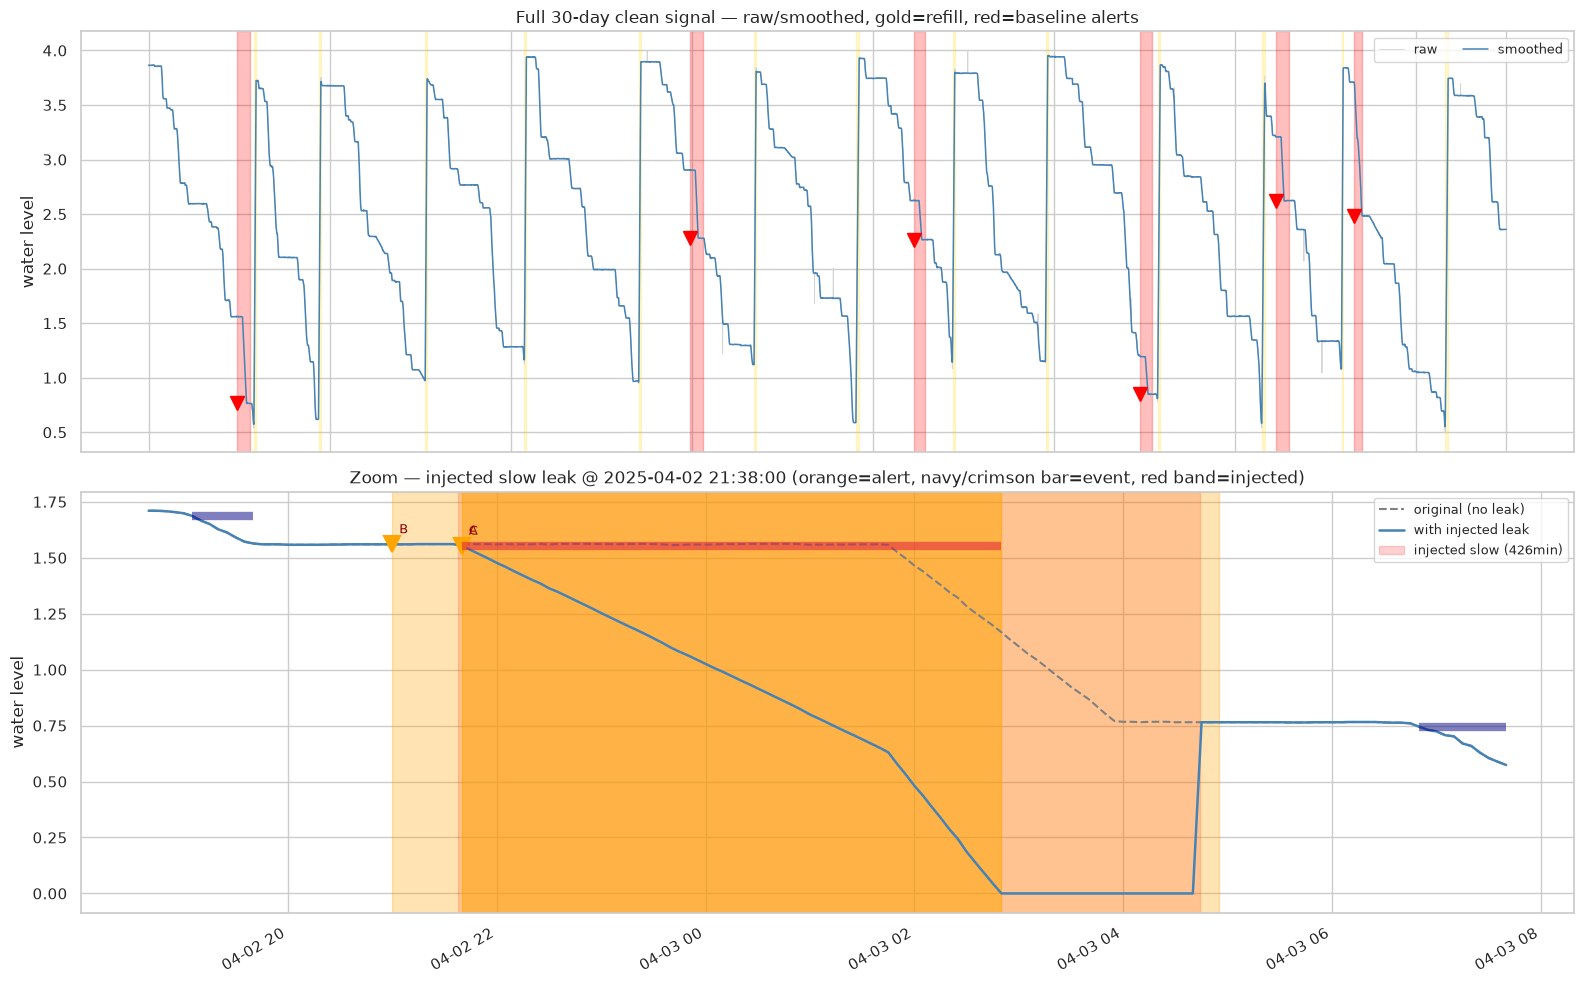

In [113]:
# pick one detected scenario for the zoom panel, else the first scenario
example = detected_scenarios[0] if detected_scenarios else scenarios[0]
inj_smooth, _, _ = inject_leak(clean_smooth, example["start"], example["duration"], example["rate"])
dfx, evx = run_pipeline(inj_smooth, cfg)
alerts = detect(evx, dfx, profile, cfg)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# --- full 30-day overview of the CLEAN series ---
ax = axes[0]
ax.plot(df.index, df["level_raw"], color="lightgray", lw=0.6, label="raw")
ax.plot(df.index, df["level_smooth"], color="steelblue", lw=1.1, label="smoothed")
# refill shade
r = df["is_refill"]
runs = (~r.eq(r.shift(1).fillna(False))).cumsum()
for _, g in df.groupby(runs):
    if g["is_refill"].iat[0]:
        ax.axvspan(g.index[0], g.index[-1], color="gold", alpha=0.18)
# baseline alerts
for a in baseline_alerts:
    ax.axvspan(a.start, a.end, color="red", alpha=0.25)
    ax.plot([a.start], [df.loc[a.start:a.end, "level_smooth"].min()], "v",
            color="red", ms=10)
ax.set_title("Full 30-day clean signal — raw/smoothed, gold=refill, red=baseline alerts")
ax.set_ylabel("water level")
ax.legend(loc="upper right", ncol=3, fontsize=9)

# --- zoomed injected-leak day ---
ax = axes[1]
win_start = example["start"] - pd.Timedelta(hours=3)
win_end = example["start"] + pd.Timedelta(minutes=example["duration"]) + pd.Timedelta(hours=3)
seg_orig = clean_smooth.loc[win_start:win_end]
seg_inj = inj_smooth.loc[win_start:win_end]
ax.plot(seg_orig.index, seg_orig.values, color="gray", lw=1.5, ls="--", label="original (no leak)")
ax.plot(seg_inj.index, seg_inj.values, color="steelblue", lw=1.8, label="with injected leak")
ax.axvspan(example["start"], example["start"] + pd.Timedelta(minutes=example["duration"]),
           color="red", alpha=0.18, label=f"injected {example['kind']} ({example['duration']}min)")
for a in alerts:
    if a.end >= win_start and a.start <= win_end:
        ax.axvspan(a.start, a.end, color="orange", alpha=0.30)
        ax.plot([a.start], [seg_inj.loc[a.start]], "v", color="orange", ms=12, mew=1.5)
        ax.annotate(a.rule, (a.start, seg_inj.loc[a.start]),
                    textcoords="offset points", xytext=(5, 8), fontsize=9, color="darkred")
# events on injected series
for _, e in evx.iterrows():
    if e["start_time"] <= win_end and e["end_time"] >= win_start:
        c = "crimson" if e["is_quiet_hour"] else "navy"
        ax.plot([e["start_time"], e["end_time"]],
                [seg_inj.loc[e["start_time"]], seg_inj.loc[e["start_time"]]],
                color=c, lw=6, alpha=0.5, solid_capstyle="butt")
ax.set_title(f"Zoom — injected {example['kind']} leak @ {example['start']} "
             f"(orange=alert, navy/crimson bar=event, red band=injected)")
ax.set_ylabel("water level")
ax.legend(loc="upper right", fontsize=9)
fig.autofmt_xdate()
plt.tight_layout(); plt.show()


## 8. Summary & Next Steps

**Approach.** This POC is intentionally explainable-first.

* **No ML / LSTM / Transformers / forecasting / Isolation Forest.**
* Detection rests on **signal processing** (rolling median + deadband +
  consecutive-rise refill mask), **consumption-event extraction**, a
  **behaviour profile** (per-hour activity probability + typical duration),
  and three **rule-based detectors**:
  * Rule A — unusual-hour long drain
  * Rule B — slow night leak via `scipy.stats.linregress` significance test
  * Rule C — hard maximum-duration cap

**Metrics reported above**: Recall, Precision, per-kind recall and the
all-important **False-Alarm Rate** measured on the unmodified 30-day signal.

**Production path (not done in this POC).** Following the project conventions
the monolithic notebook would be split into `src/services/` with one stage
per module behind interfaces (Strategy + Factory), `Config` upgraded to a
`pydantic-settings` class, profiles & events persisted to PostgreSQL, and
rules versioned. An ML layer would only be introduced **after** it is shown
to beat this baseline on False-Alarm Rate and precision.
